In [24]:
# Import dependencies

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import f_oneway

In [25]:
p_sales = pd.read_csv("product_sales.csv")

p_sales.head()

,week,sales_method,customer_id,nb_sold,revenue,years_as_customer,nb_site_visits,state
0,2,Email,2e72d641-95ac-497b-bbf8-4861764a7097,10,NaN,0,24,Arizona
1,6,Email + Call,3998a98d-70f5-44f7-942e-789bb8ad2fe7,15,225.47,1,28,Kansas
2,5,Call,d1de9884-8059-4065-b10f-86eef57e4a44,11,52.55,6,26,Wisconsin
3,4,Email,78aa75a4-ffeb-4817-b1d0-2f030783c5d7,11,NaN,3,25,Indiana
4,3,Email,10e6d446-10a5-42e5-8210-1b5438f70922,9,90.49,0,28,Illinois


In [26]:
p_sales.shape

(15000, 8)

In [27]:
p_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   week               15000 non-null  int64  
 1   sales_method       15000 non-null  object 
 2   customer_id        15000 non-null  object 
 3   nb_sold            15000 non-null  int64  
 4   revenue            13926 non-null  float64
 5   years_as_customer  15000 non-null  int64  
 6   nb_site_visits     15000 non-null  int64  
 7   state              15000 non-null  object 
dtypes: float64(1), int64(4), object(3)
memory usage: 937.6+ KB


In [28]:
missing_values = p_sales['revenue'].isnull().sum()
missing_values

1074

 MISSING VALUES

In [29]:
# Calculate the average price per item for entries where revenue is known
known_revenue_data = p_sales.dropna(subset=["revenue"])
total_revenue = known_revenue_data["revenue"].sum()
total_items_sold = known_revenue_data["nb_sold"].sum()

# Average price per item
average_price_per_item = total_revenue / total_items_sold

# Fill missing revenue by multiplying the number of products sold by the average price
p_sales['revenue_filled'] = p_sales['revenue'].fillna(p_sales['nb_sold'] * average_price_per_item)

# Verify the result
missing_revenue_filled = p_sales['revenue_filled'].isnull().sum()
p_sales[['revenue', 'revenue_filled']].head(), missing_revenue_filled

# Check for missing values in the 'revenue_filled' column
missing_revenue_filled_check = p_sales['revenue_filled'].isnull().sum()

missing_revenue_filled_check



0

INCONSISTENT LABELLING

In [30]:
# Step 1: Check for duplicate rows
duplicate_rows = p_sales.duplicated().sum()

# Step 2: Check unique values in the 'sales_method' and 'state' columns for consistency
sales_method_unique = p_sales['sales_method'].unique()
state_unique = p_sales['state'].unique()

# Displaying results for duplicates and unique values in key columns
duplicate_rows, sales_method_unique, state_unique


(0,
 array(['Email', 'Email + Call', 'Call', 'em + call', 'email'],
       dtype=object),
 array(['Arizona', 'Kansas', 'Wisconsin', 'Indiana', 'Illinois',
        'Mississippi', 'Georgia', 'Oklahoma', 'Massachusetts', 'Missouri',
        'Texas', 'New York', 'Maryland', 'California', 'Tennessee',
        'Pennsylvania', 'North Dakota', 'Florida', 'Michigan',
        'North Carolina', 'Hawaii', 'Colorado', 'Louisiana', 'Virginia',
        'New Mexico', 'Arkansas', 'Alaska', 'Oregon', 'New Hampshire',
        'Ohio', 'New Jersey', 'Connecticut', 'Iowa', 'Montana',
        'Washington', 'Kentucky', 'Alabama', 'Nebraska', 'South Carolina',
        'Minnesota', 'South Dakota', 'Delaware', 'Maine', 'Utah',
        'West Virginia', 'Vermont', 'Rhode Island', 'Nevada', 'Idaho',
        'Wyoming'], dtype=object))

In [31]:
# Step 3: Standardize the 'sales_method' column to fix inconsistencies
p_sales['sales_method_cleaned'] = p_sales['sales_method'].str.strip().str.title()

# Replace common inconsistencies
p_sales['sales_method_cleaned'] = p_sales['sales_method_cleaned'].replace({
    'Email': 'Email',
    'Email + Call': 'Email + Call',
    'Em + Call': 'Email + Call',
    'Call': 'Call'
})

# Verify the cleaned unique values in 'sales_method_cleaned'
sales_method_cleaned_unique = p_sales['sales_method_cleaned'].unique()

# Display the cleaned sales methods
sales_method_cleaned_unique


array(['Email', 'Email + Call', 'Call'], dtype=object)

OUTLIERS

In [32]:
# Step 4: Checking for outliers in the numerical columns
# Use the describe function to get an overview of the distribution and detect any anomalies.

numerical_summary = p_sales[['nb_sold', 'revenue_filled', 'years_as_customer']].describe()

numerical_summary


,nb_sold,revenue_filled,years_as_customer
count,15000.000000,15000.000000,15000.000000
mean,10.084667,94.352199,4.965933
std,1.812213,46.001824,5.044952
min,7.000000,32.540000,0.000000
25%,9.000000,53.040000,1.000000
50%,10.000000,90.305000,3.000000
75%,11.000000,107.582500,7.000000
max,16.000000,238.320000,63.000000


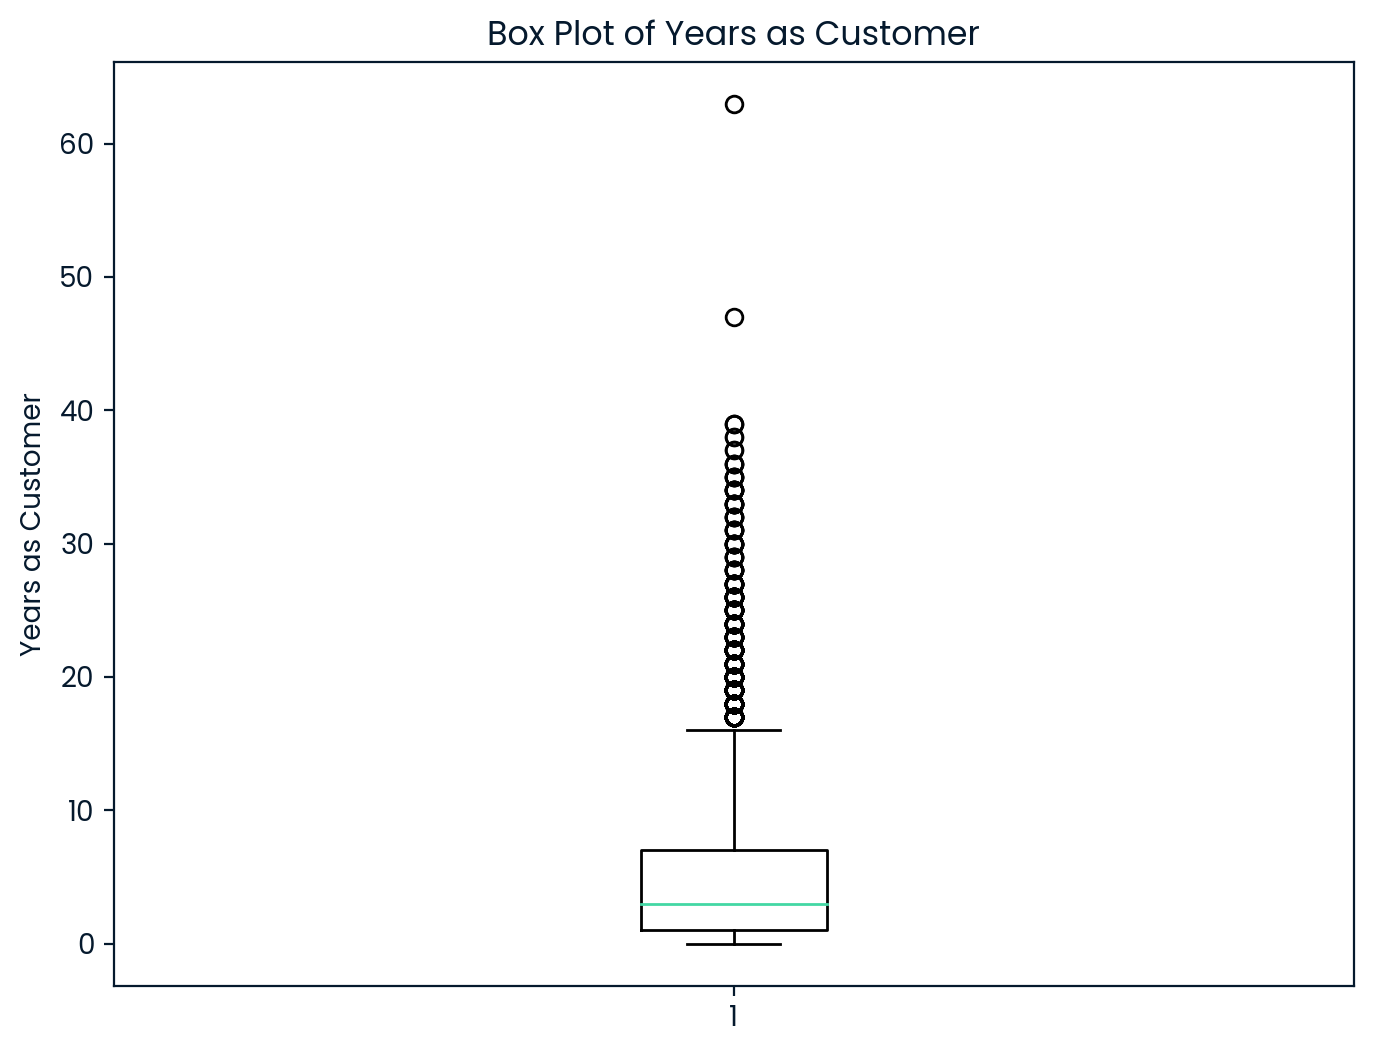

In [33]:
# Check for outliers in years_as_customer column
# Plotting a box plot for the 'years_as_customer' column
plt.figure(figsize=(8, 6))
plt.boxplot(p_sales['years_as_customer'])
plt.title('Box Plot of Years as Customer')
plt.ylabel('Years as Customer')
plt.show()

In [34]:
# Cap outliers in 'years_as_customer' column
p_sales['years_as_customer'] = p_sales['years_as_customer'].apply(lambda x: min(x, 40))

# Verify the changes
print(p_sales['years_as_customer'].describe())

count    15000.000000
mean         4.963933
std          5.027211
min          0.000000
25%          1.000000
50%          3.000000
75%          7.000000
max         40.000000
Name: years_as_customer, dtype: float64


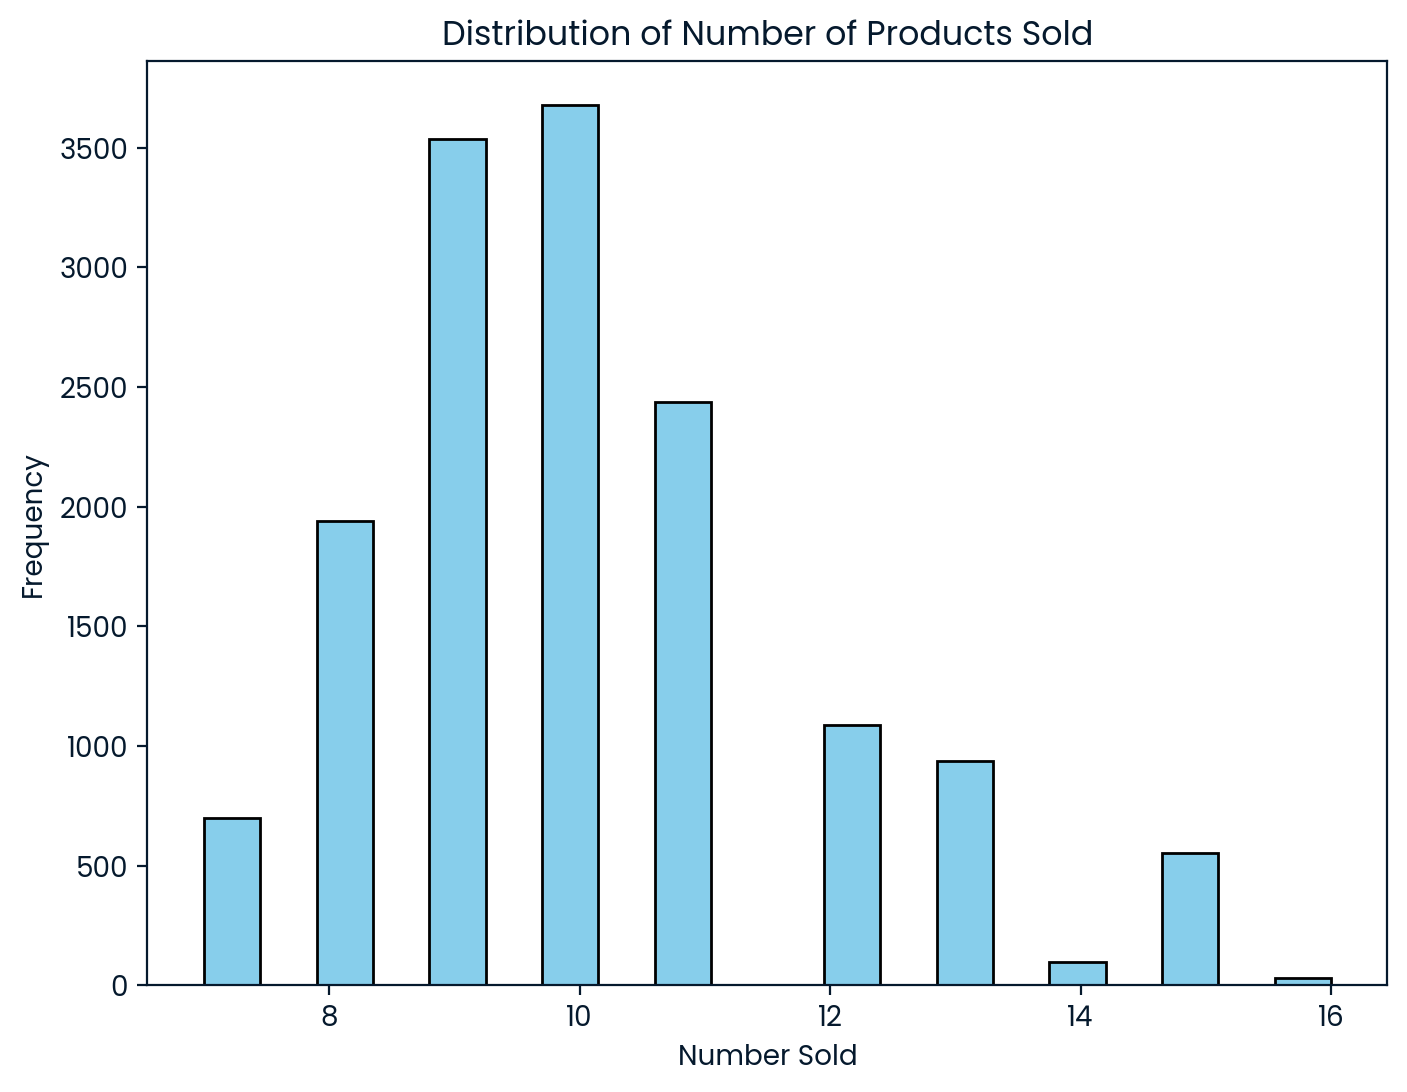

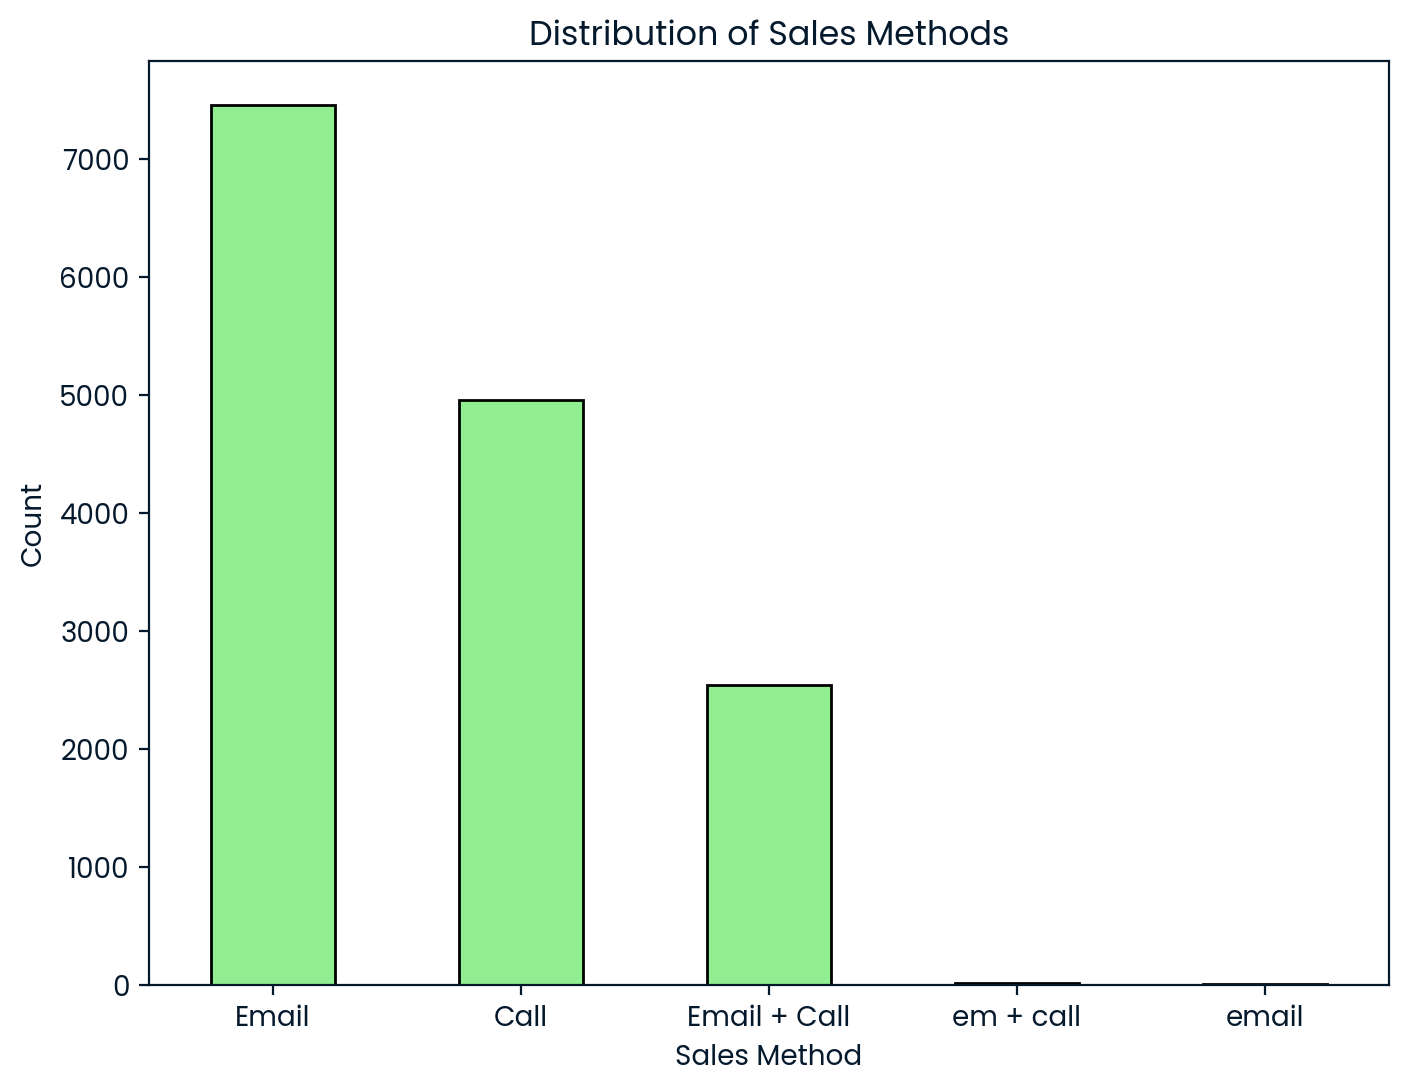

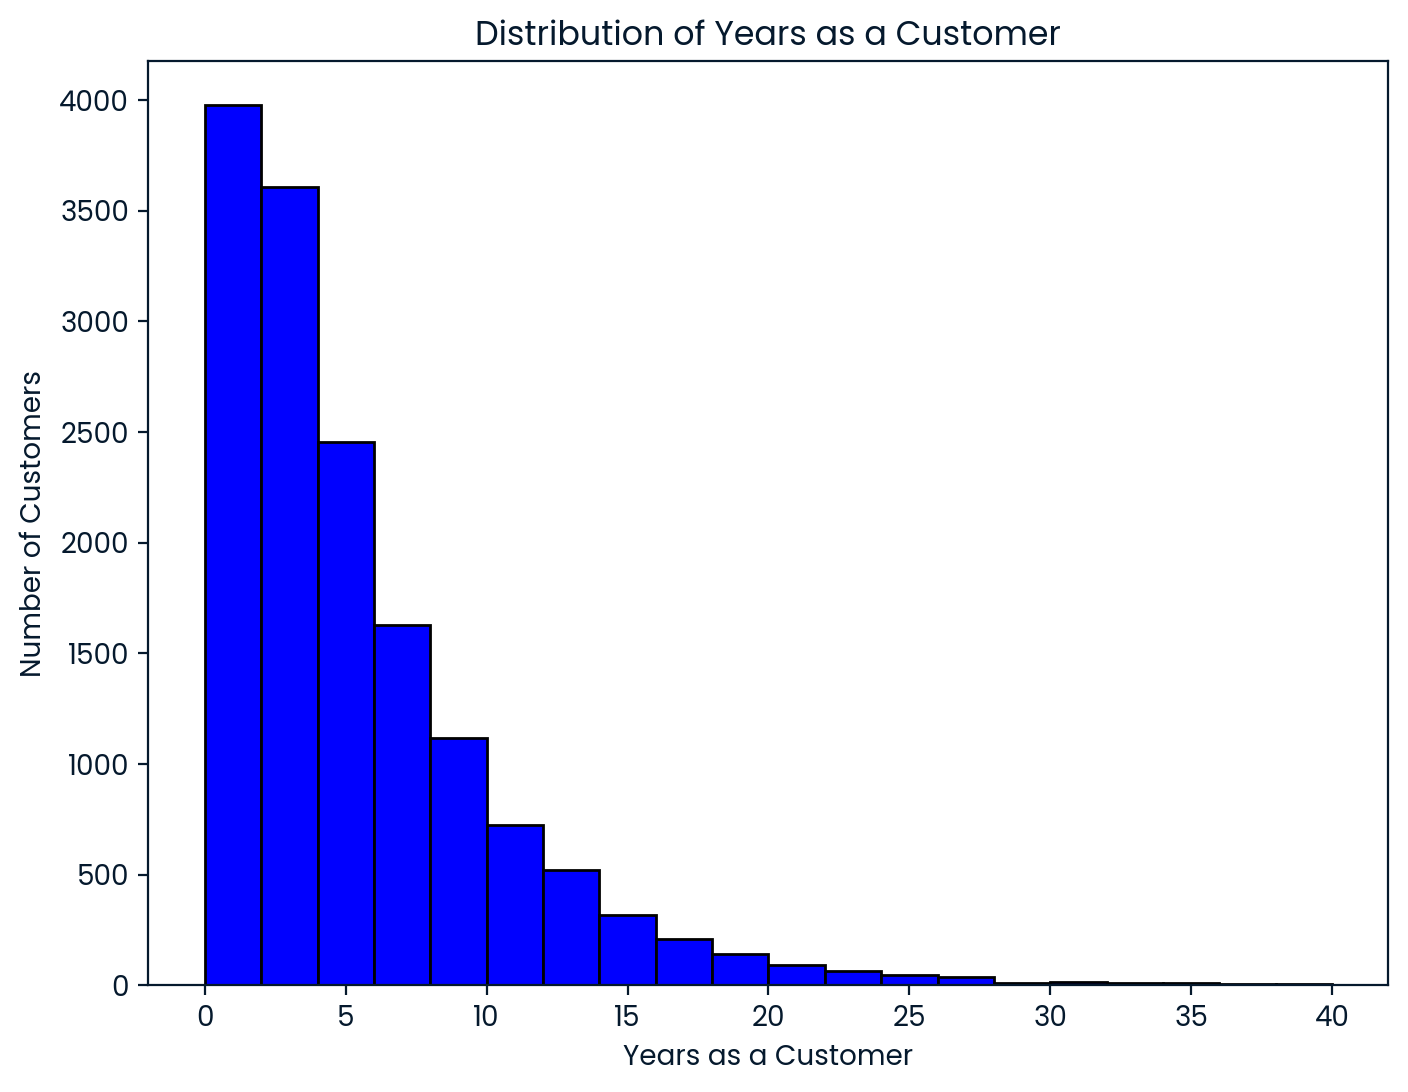

In [35]:
# Distribution of number of products sold (nb_sold)
plt.figure(figsize=(8, 6))
plt.hist(p_sales['nb_sold'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Number of Products Sold')
plt.xlabel('Number Sold')
plt.ylabel('Frequency')
plt.show()

# Bar chart of sales method distribution
plt.figure(figsize=(8, 6))
p_sales['sales_method'].value_counts().plot(kind='bar', color='lightgreen', edgecolor='black')
plt.title('Distribution of Sales Methods')
plt.xlabel('Sales Method')
plt.xticks(rotation=0)
plt.ylabel('Count')
plt.show()


# Create a histogram to visualize the distribution of 'years_as_customer' to detect any trends
# Plot the distribution of years as a customer
plt.figure(figsize=(8, 6))
plt.hist(p_sales['years_as_customer'], bins=20, color='blue', edgecolor='black')
plt.title('Distribution of Years as a Customer')
plt.xlabel('Years as a Customer')
plt.ylabel('Number of Customers')
plt.show()



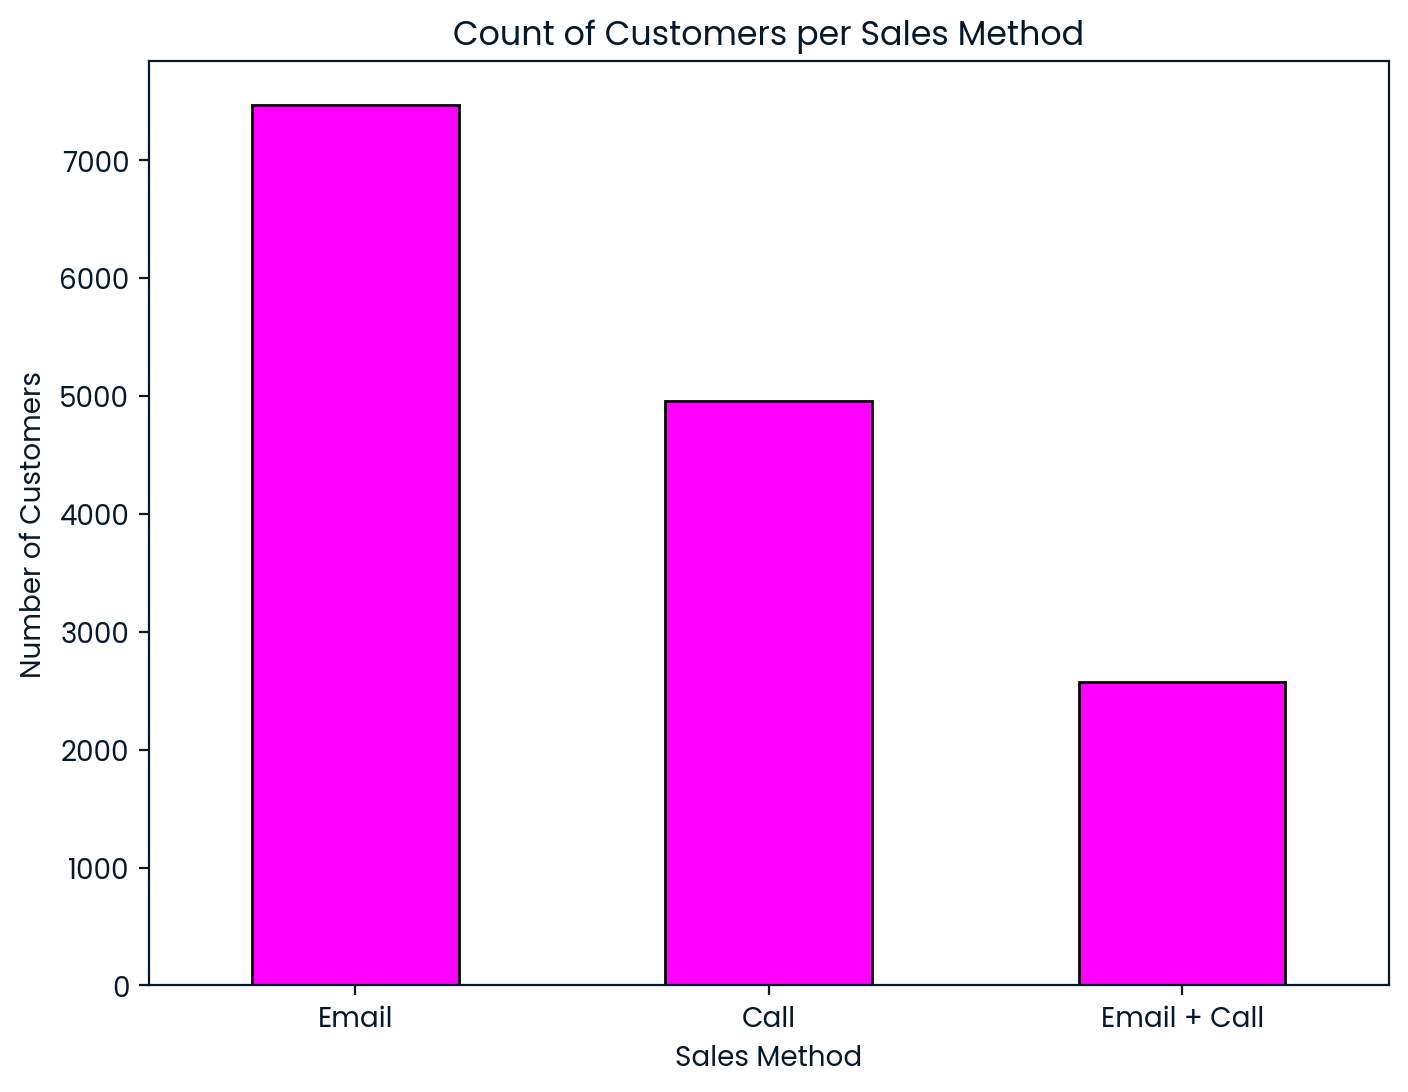

In [36]:
# Count the number of customers for each sales method
customer_count_by_method = p_sales['sales_method_cleaned'].value_counts()

# Display the customer counts
customer_count_by_method


# Plot the count of customers per sales method
plt.figure(figsize=(8, 6))
customer_count_by_method.plot(kind='bar', color='magenta', edgecolor='black')
plt.title('Count of Customers per Sales Method')
plt.xlabel('Sales Method')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.show()



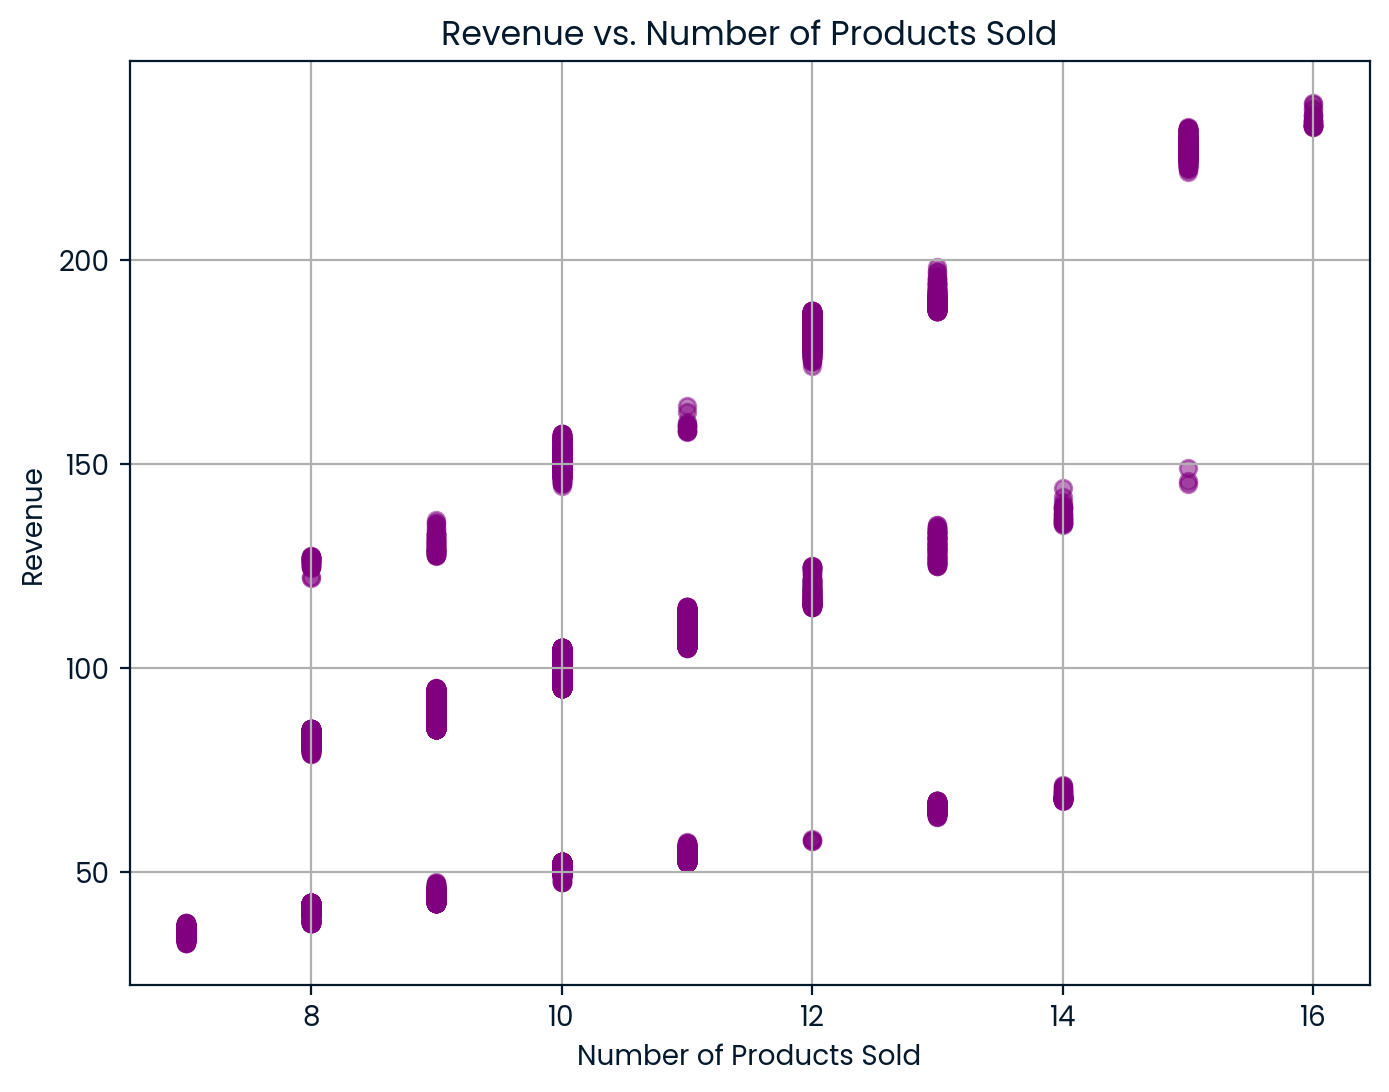

In [37]:
# Relationship between revenue and number of products sold
plt.figure(figsize=(8, 6))
plt.scatter(p_sales['nb_sold'], p_sales['revenue'], color='purple', alpha=0.5)
plt.title('Revenue vs. Number of Products Sold')
plt.xlabel('Number of Products Sold')
plt.ylabel('Revenue')
plt.grid(True)
plt.show()

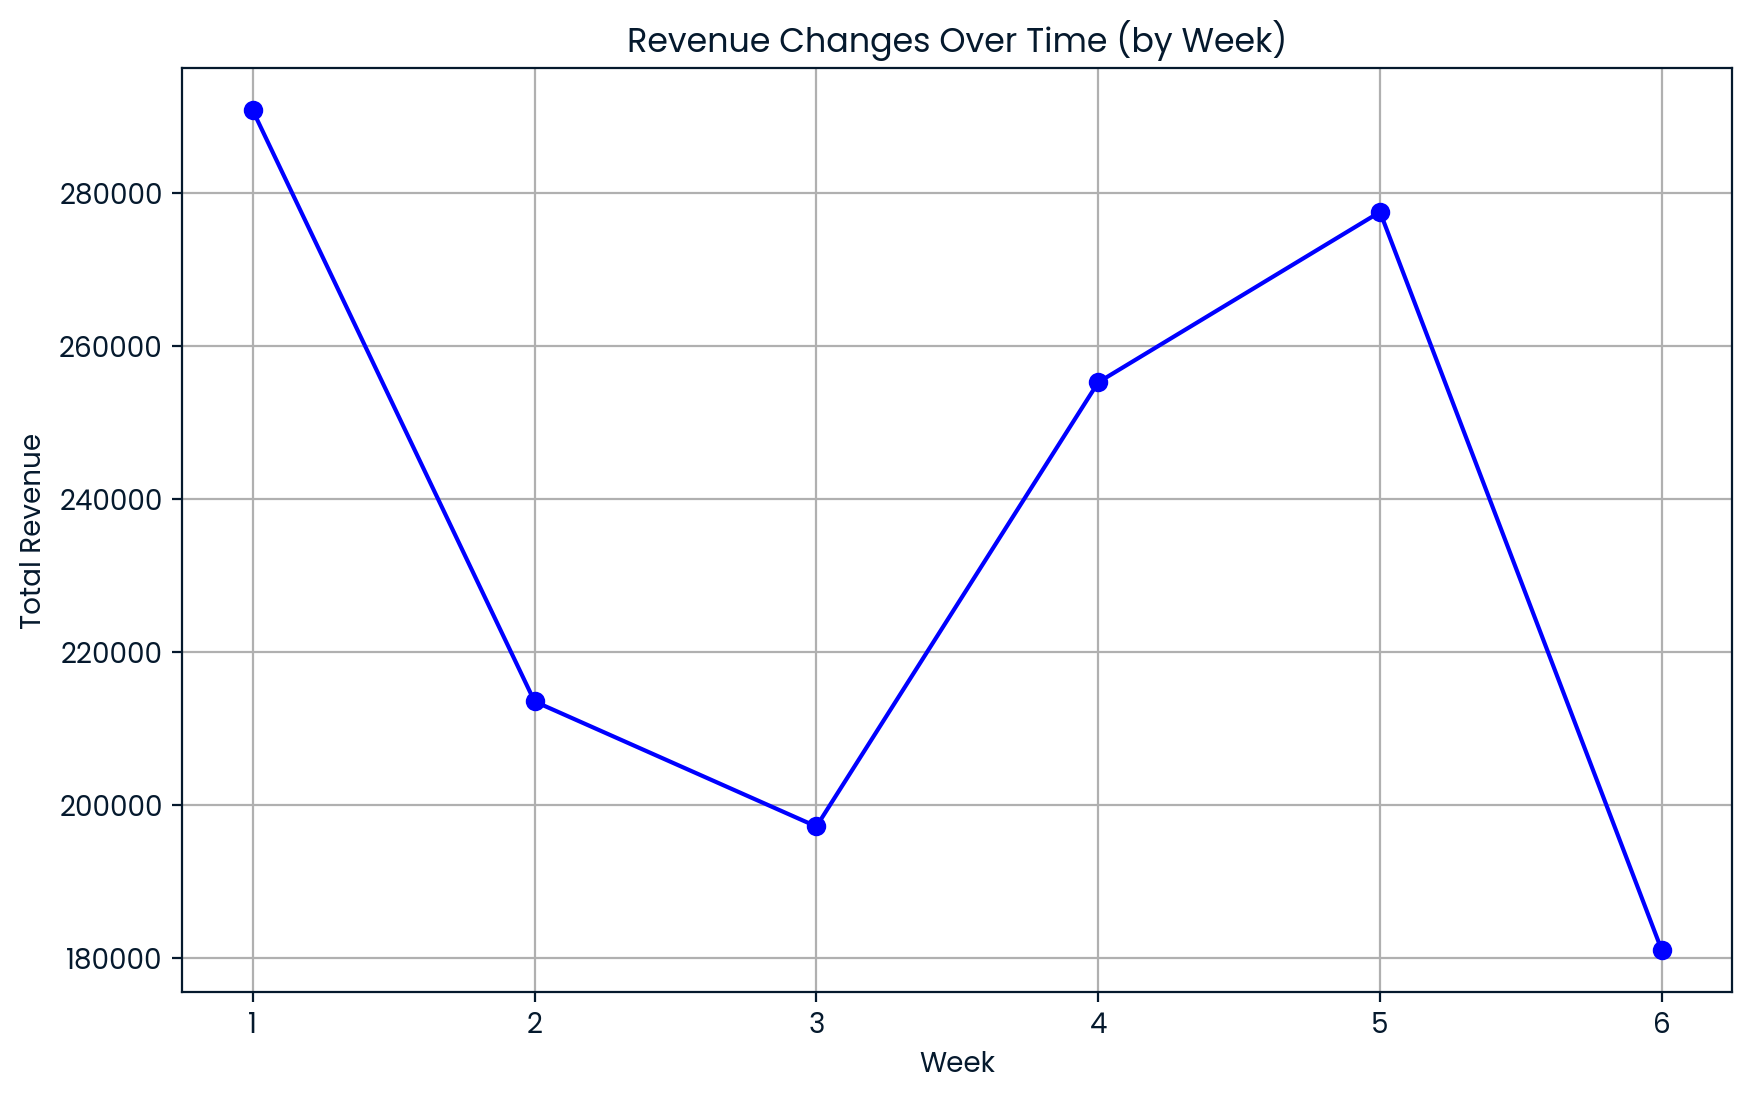

In [38]:
# Create a line plot to analyze revenue changes over time (by week)
# Group the data by 'week' and sum the 'revenue_filled' for each week

revenue_by_week = p_sales.groupby('week')['revenue_filled'].sum()

# Plot the revenue changes over time
plt.figure(figsize=(10, 6))
plt.plot(revenue_by_week.index, revenue_by_week.values, marker='o', color='blue', linestyle='-')
plt.title('Revenue Changes Over Time (by Week)')
plt.xlabel('Week')
plt.ylabel('Total Revenue')
plt.grid(True)
plt.show()


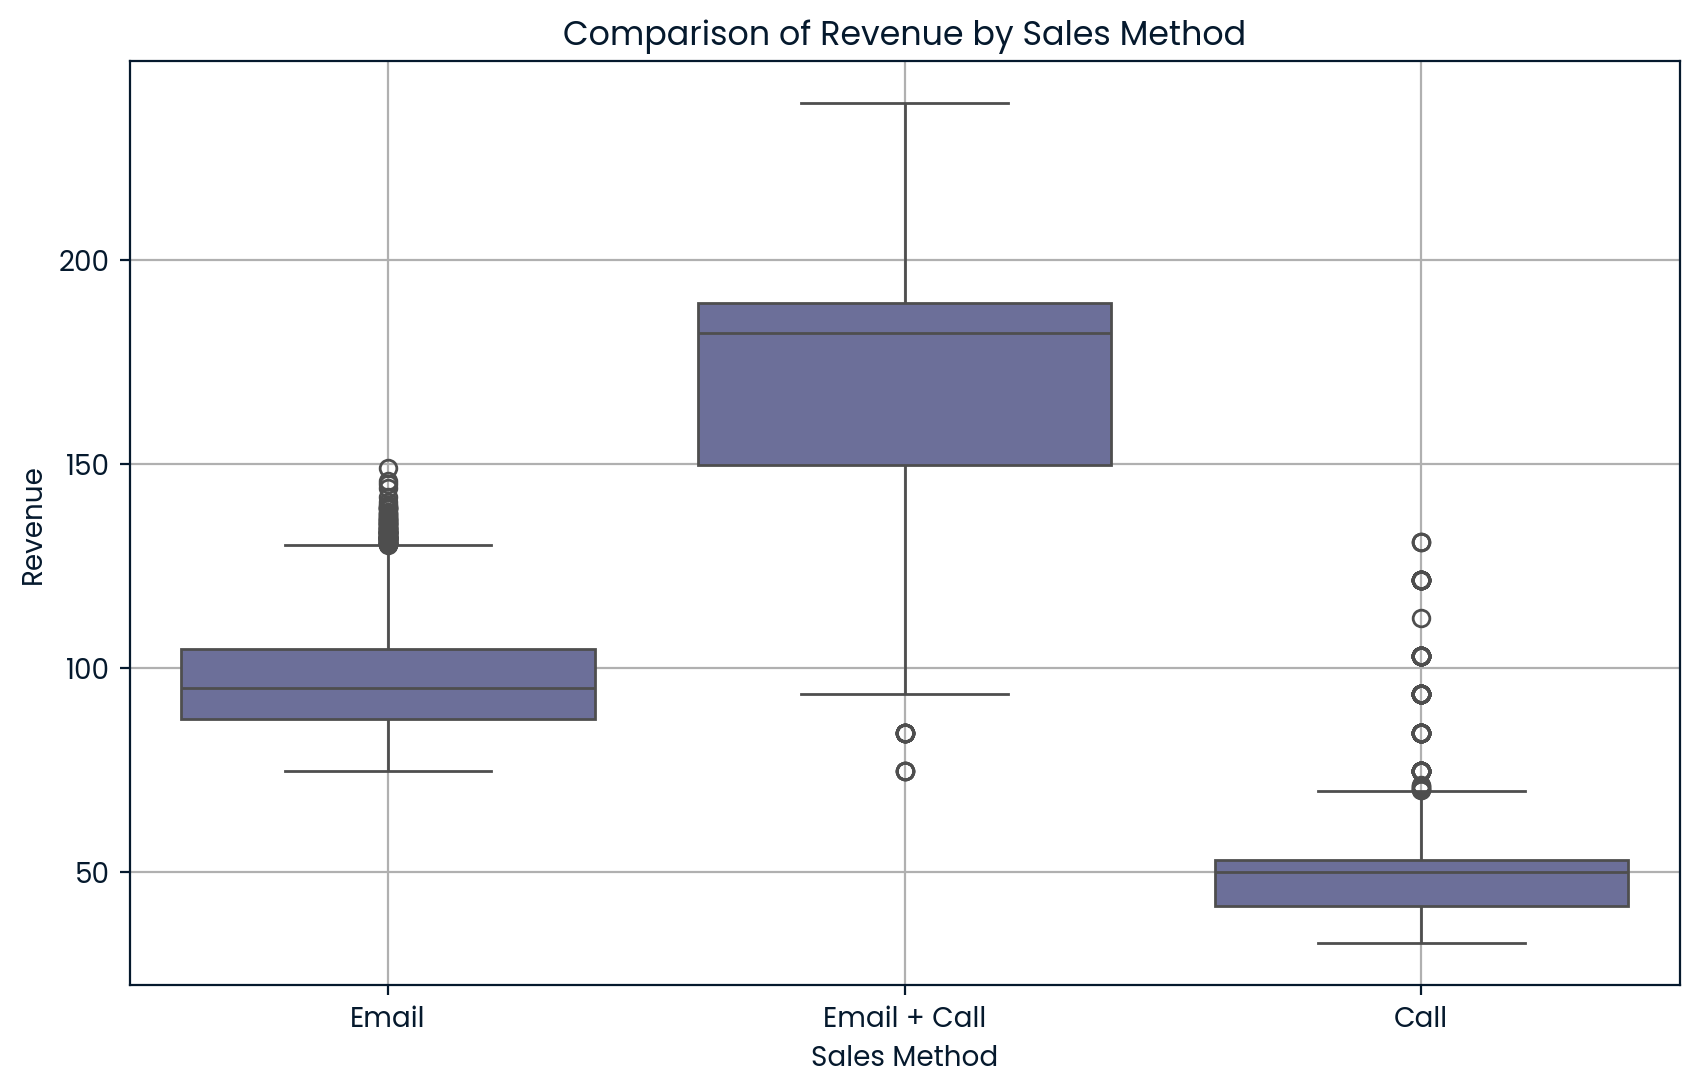

In [39]:
# Create a boxplot to compare the distribution of revenue across the different sales methods

plt.figure(figsize=(10, 6))
sns.boxplot(x='sales_method_cleaned', y='revenue_filled', data=p_sales)
plt.title('Comparison of Revenue by Sales Method')
plt.xlabel('Sales Method')
plt.ylabel('Revenue')
plt.grid(True)
plt.show()


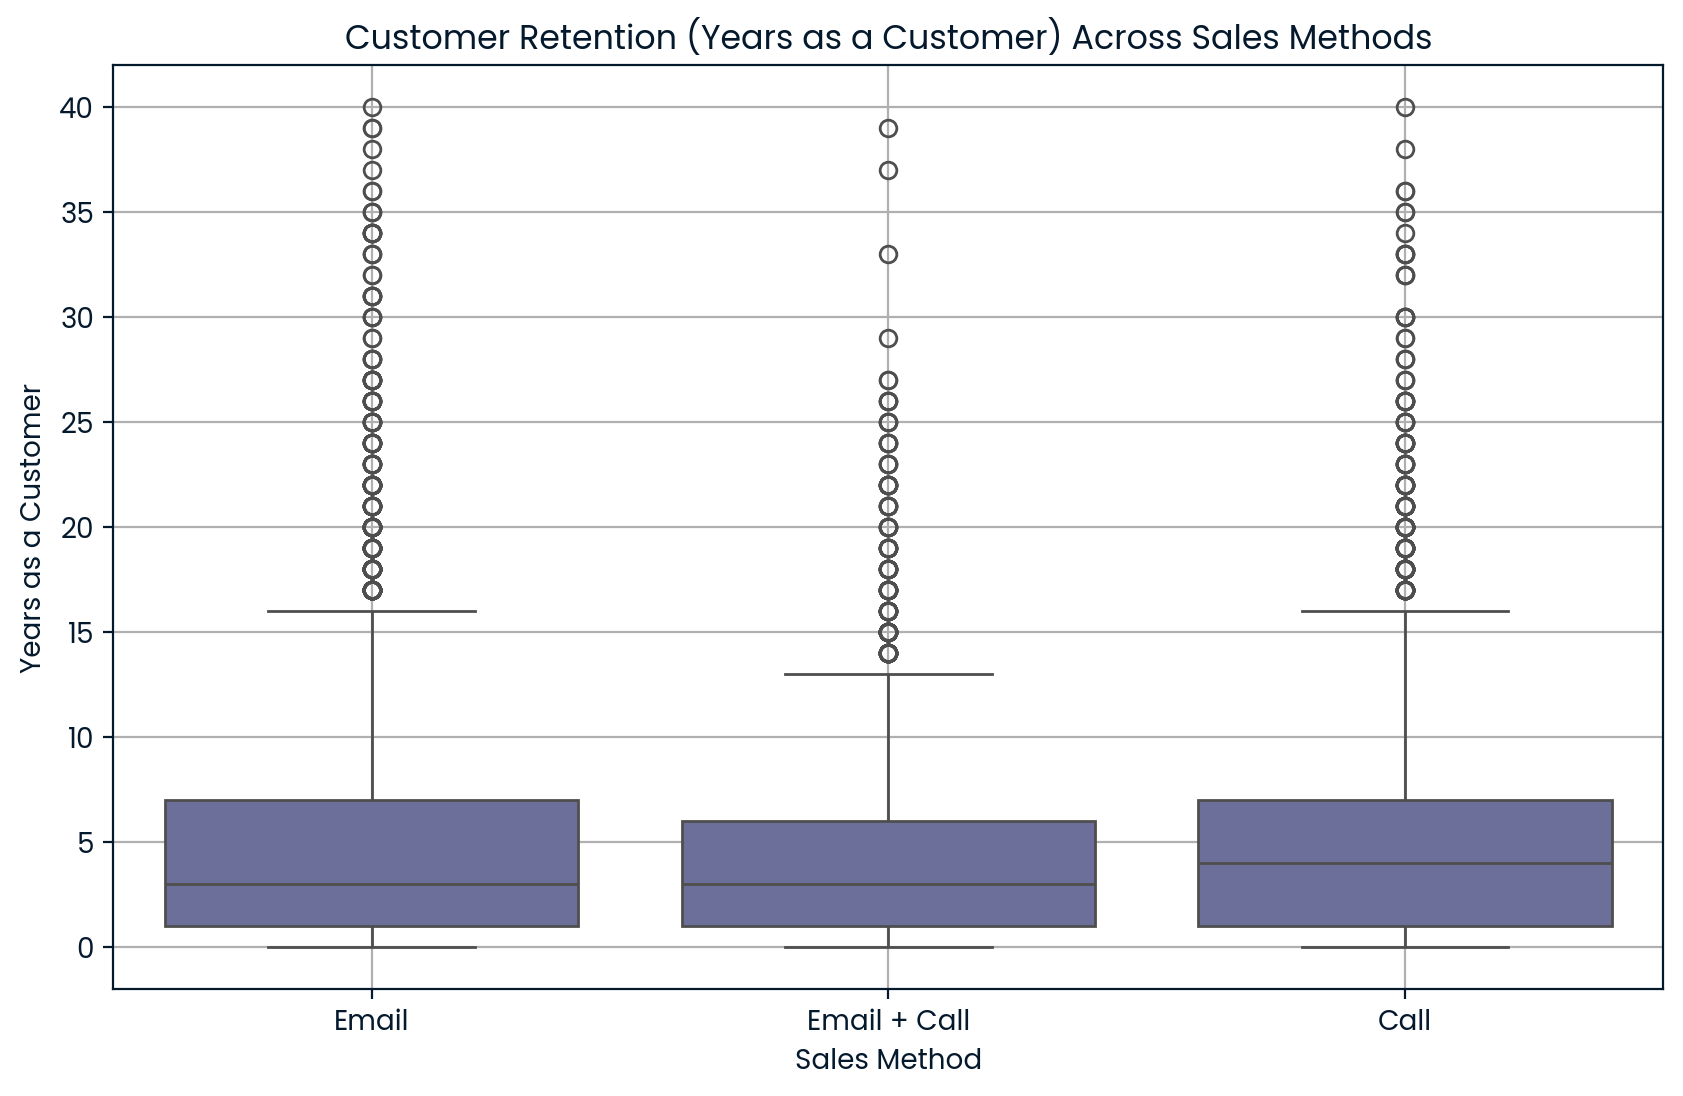

sales_method_cleaned
Call            5.175333
Email           4.980713
Email + Call    4.507387
Name: years_as_customer, dtype: float64

In [40]:
# Calculate the average years as a customer for each sales method
retention_by_method = p_sales.groupby('sales_method_cleaned')['years_as_customer'].mean()

# Create a boxplot to visualize the distribution of years as a customer by sales method
plt.figure(figsize=(10, 6))
sns.boxplot(x='sales_method_cleaned', y='years_as_customer', data=p_sales)

# Set plot titles and labels
plt.title('Customer Retention (Years as a Customer) Across Sales Methods')
plt.xlabel('Sales Method')
plt.ylabel('Years as a Customer')
plt.grid(True)

# Show the plot
plt.show()

# Display the average years as customer by sales method
retention_by_method


<Figure size 1000x600 with 0 Axes>

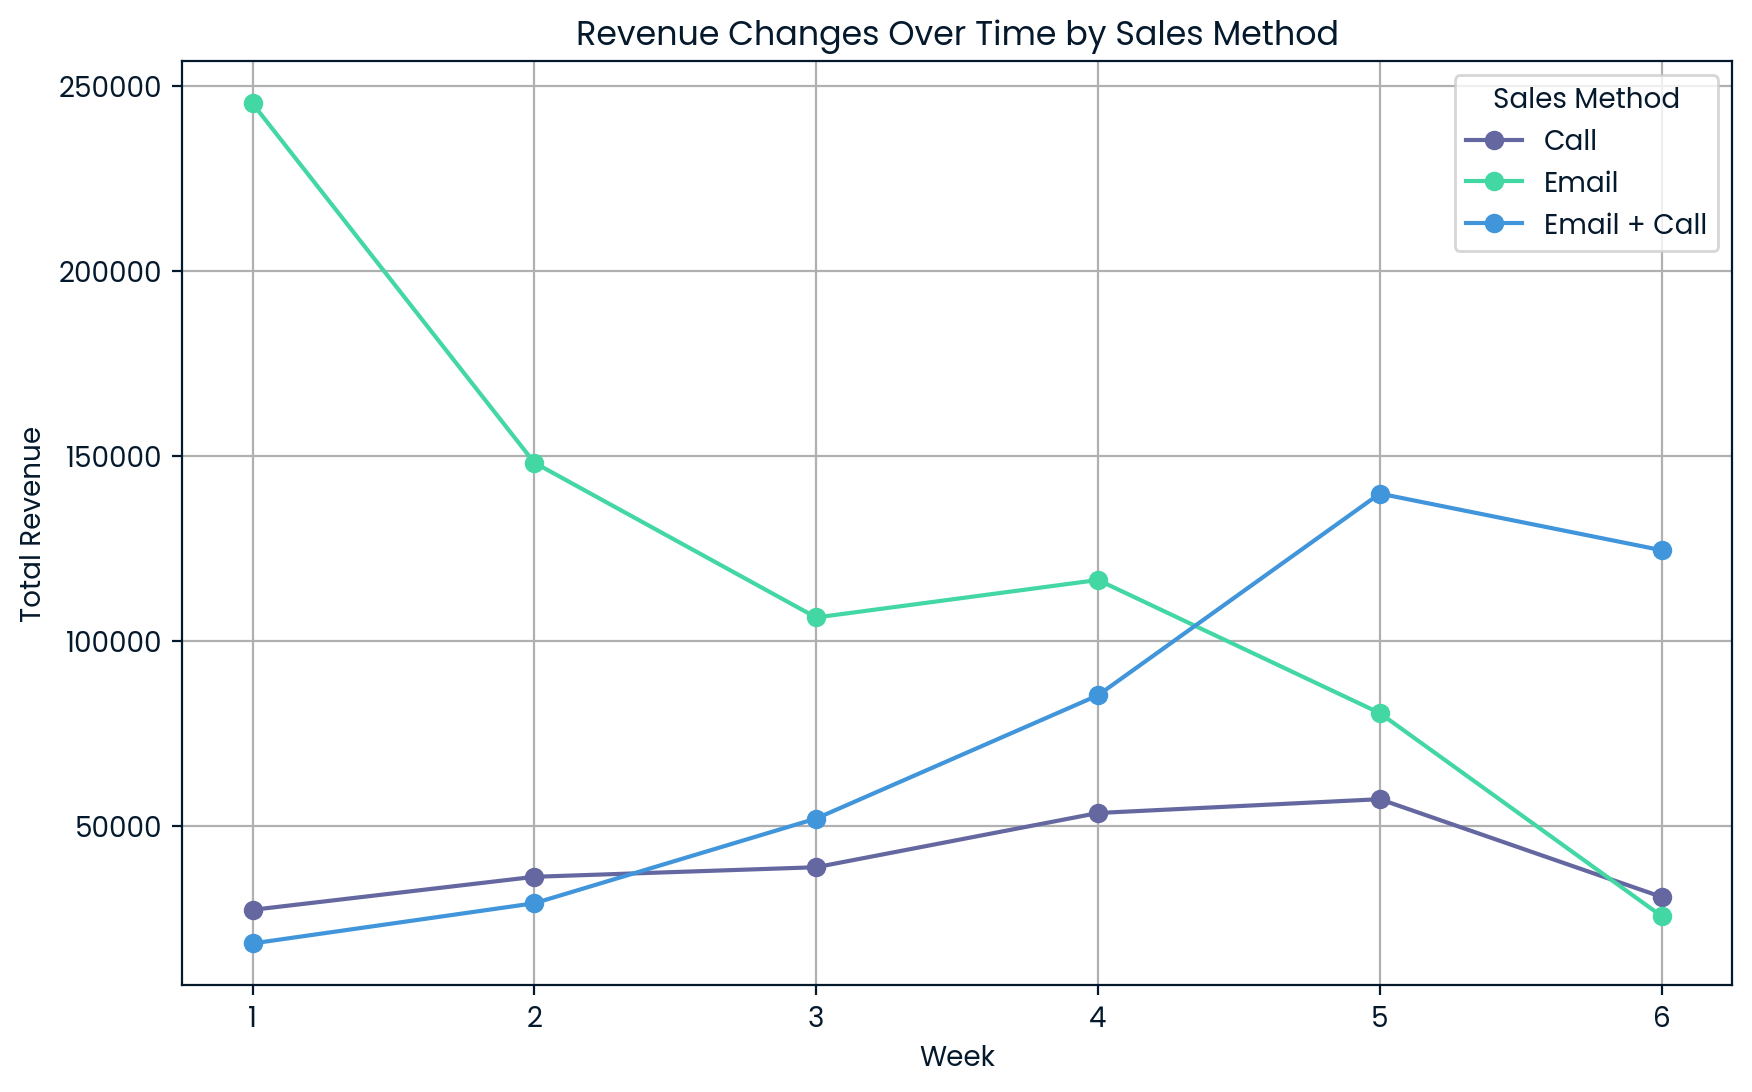

In [41]:
# Group the data by 'week' and 'sales_method_cleaned' to sum the revenue for each method per week
revenue_by_week_method = p_sales.groupby(['week', 'sales_method_cleaned'])['revenue_filled'].sum().unstack()

# Plot revenue changes over time, broken down by sales method
plt.figure(figsize=(10, 6))
revenue_by_week_method.plot(kind='line', marker='o', linestyle='-', figsize=(10,6))
plt.title('Revenue Changes Over Time by Sales Method')
plt.xlabel('Week')
plt.ylabel('Total Revenue')
plt.grid(True)
plt.legend(title='Sales Method')
plt.show()


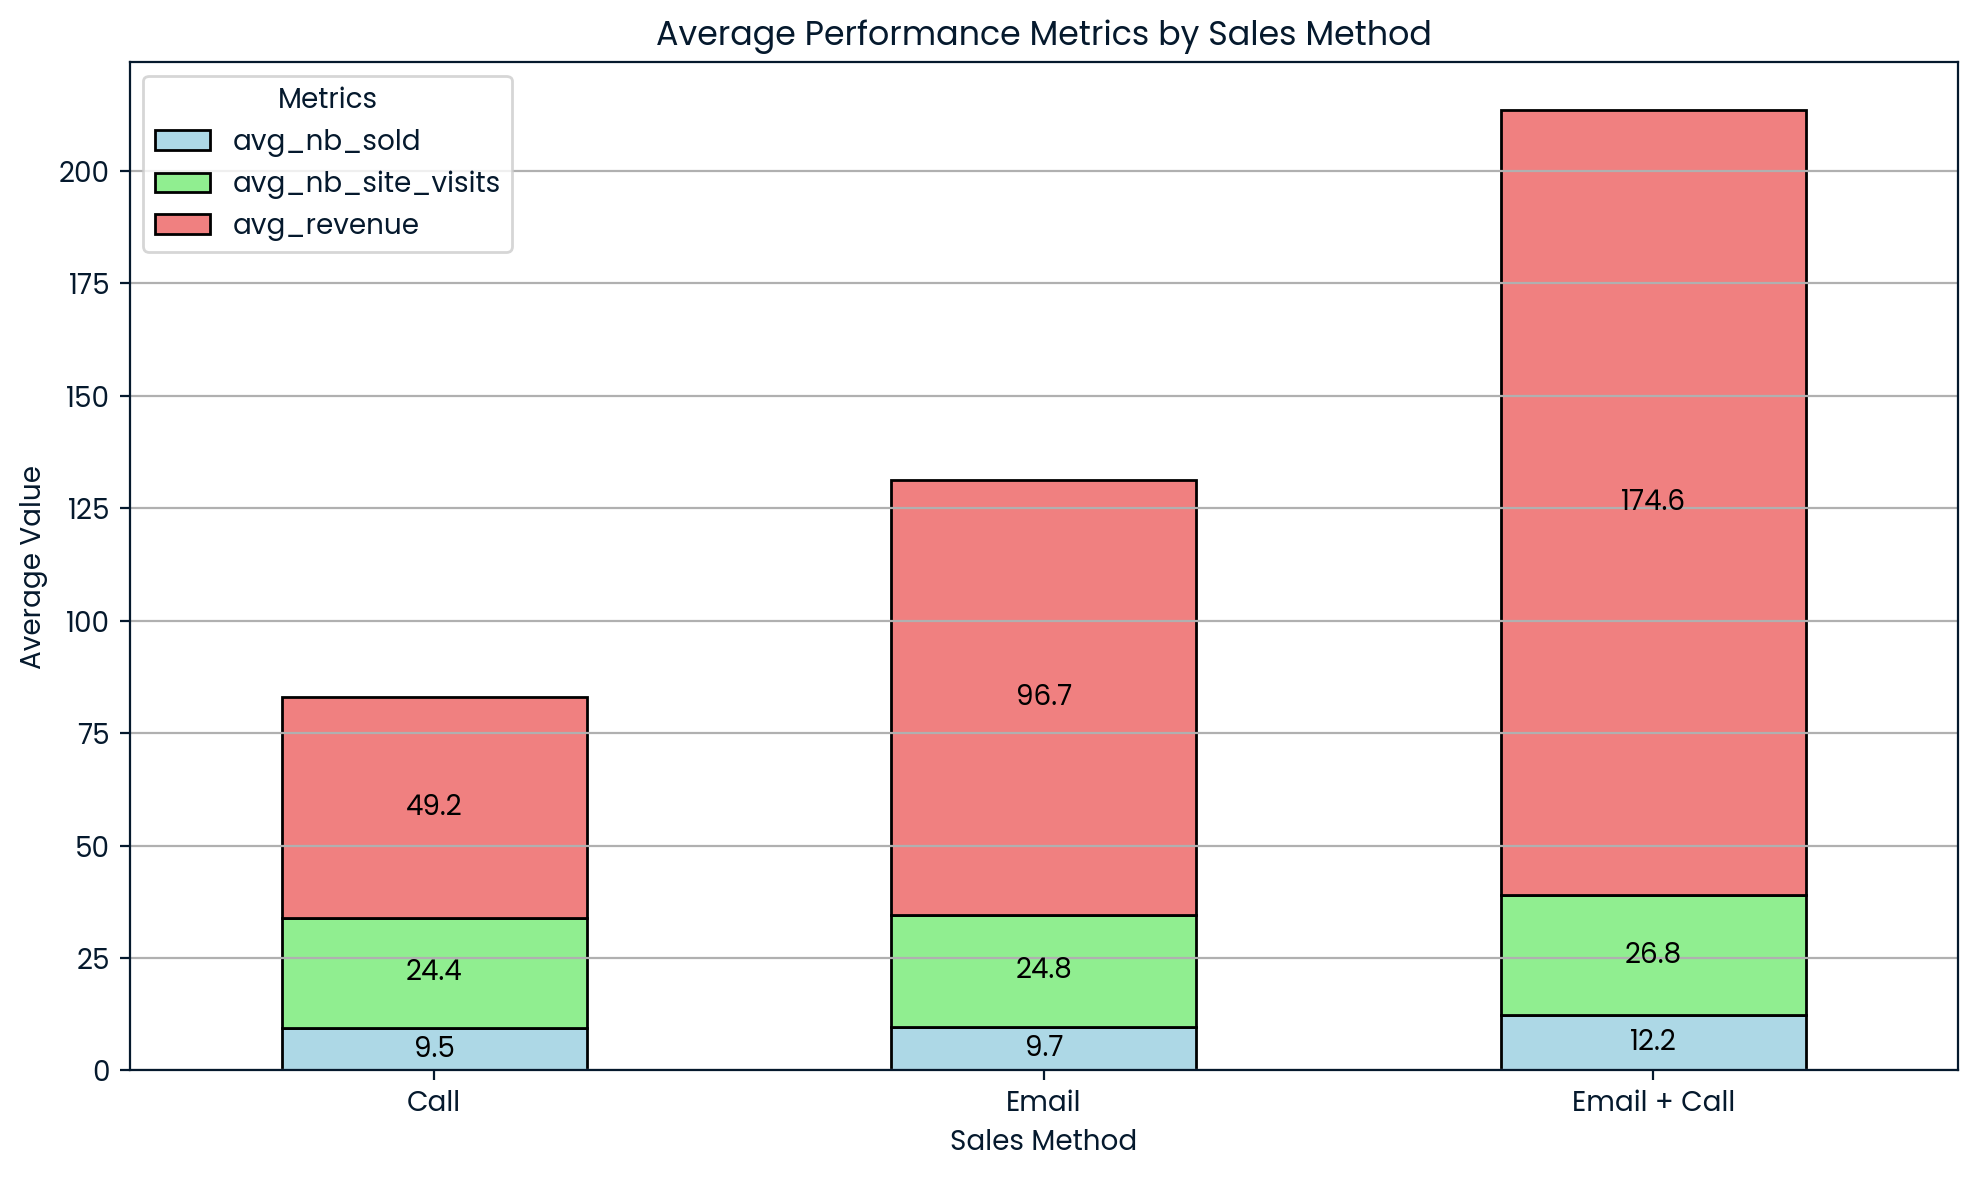

In [42]:
# Calculate the average performance metrics for number of products sold, number of site visits, and revenue by sales method
average_metrics_by_method_stacked = p_sales.groupby('sales_method_cleaned').agg(
    avg_nb_sold=('nb_sold', 'mean'),
    avg_nb_site_visits=('nb_site_visits', 'mean'),
    avg_revenue=('revenue_filled', 'mean')
)


# Plot the stacked bar chart with actual figures displayed on the bars

# Plot the stacked bar chart with the original values
ax = average_metrics_by_method_stacked.plot(kind='bar', stacked=True, figsize=(10, 6), color=['lightblue', 'lightgreen', 'lightcoral'], edgecolor='black')

# Add the actual values on the bars
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    if height > 0:
        ax.text(x + width/2, y + height/2, f'{height:.1f}', ha='center', va='center', fontsize=10, color='black')

# Set the plot titles and labels
plt.title('Average Performance Metrics by Sales Method')
plt.xlabel('Sales Method')
plt.ylabel('Average Value')
plt.xticks(rotation=0)
plt.legend(title='Metrics', loc='upper left')
plt.grid(True, axis='y')

# Show the plot
plt.tight_layout()
plt.show()



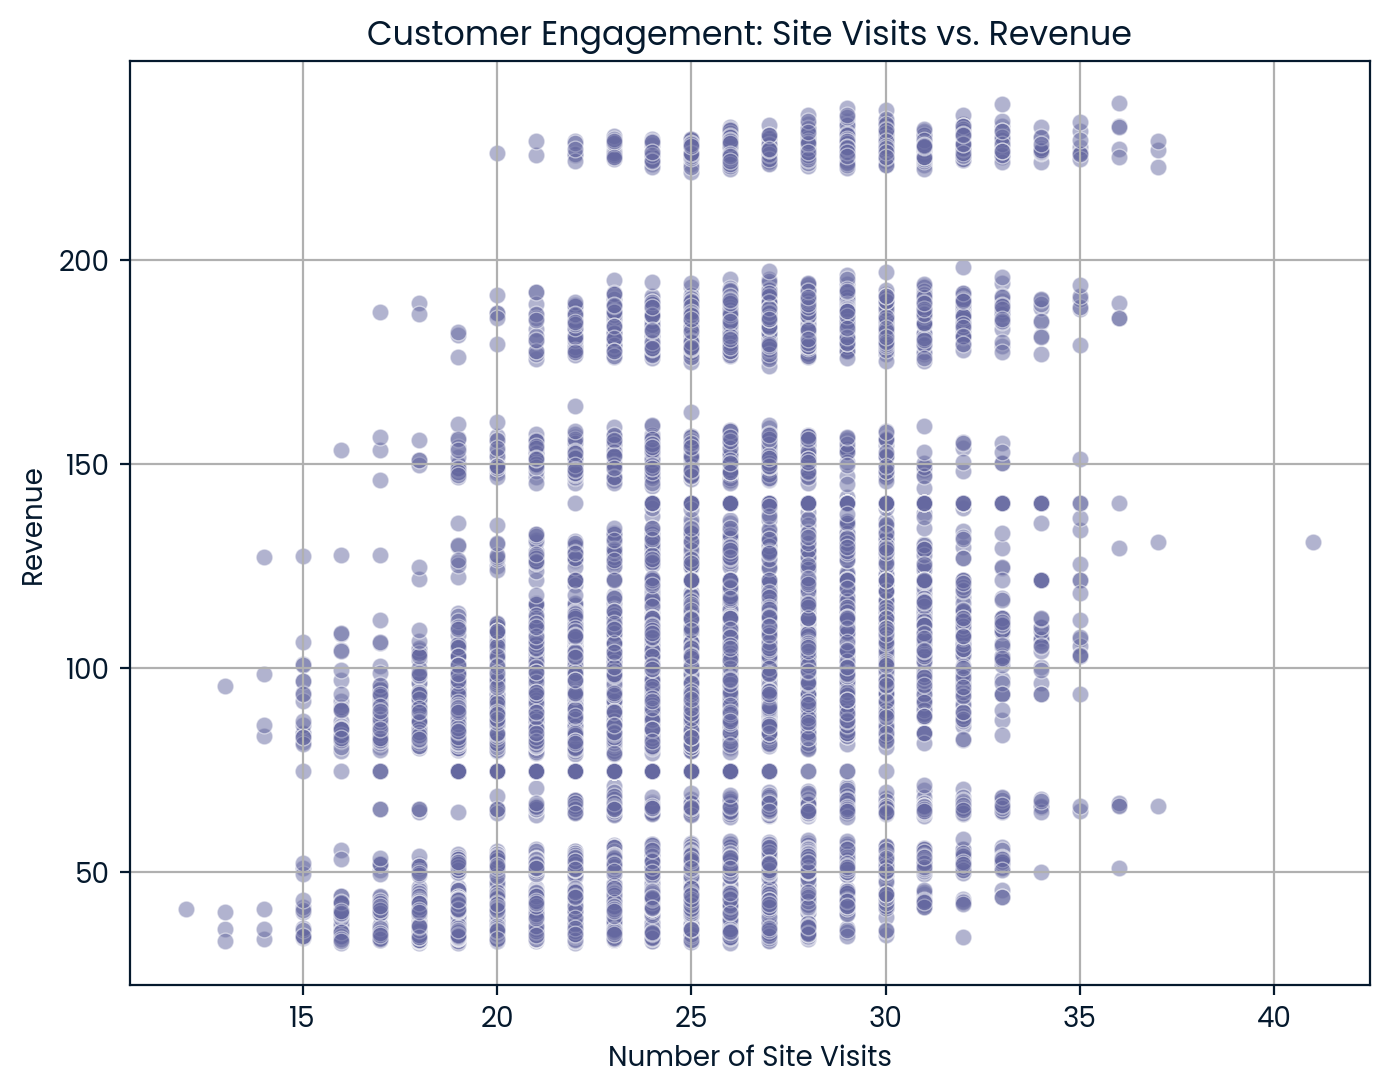

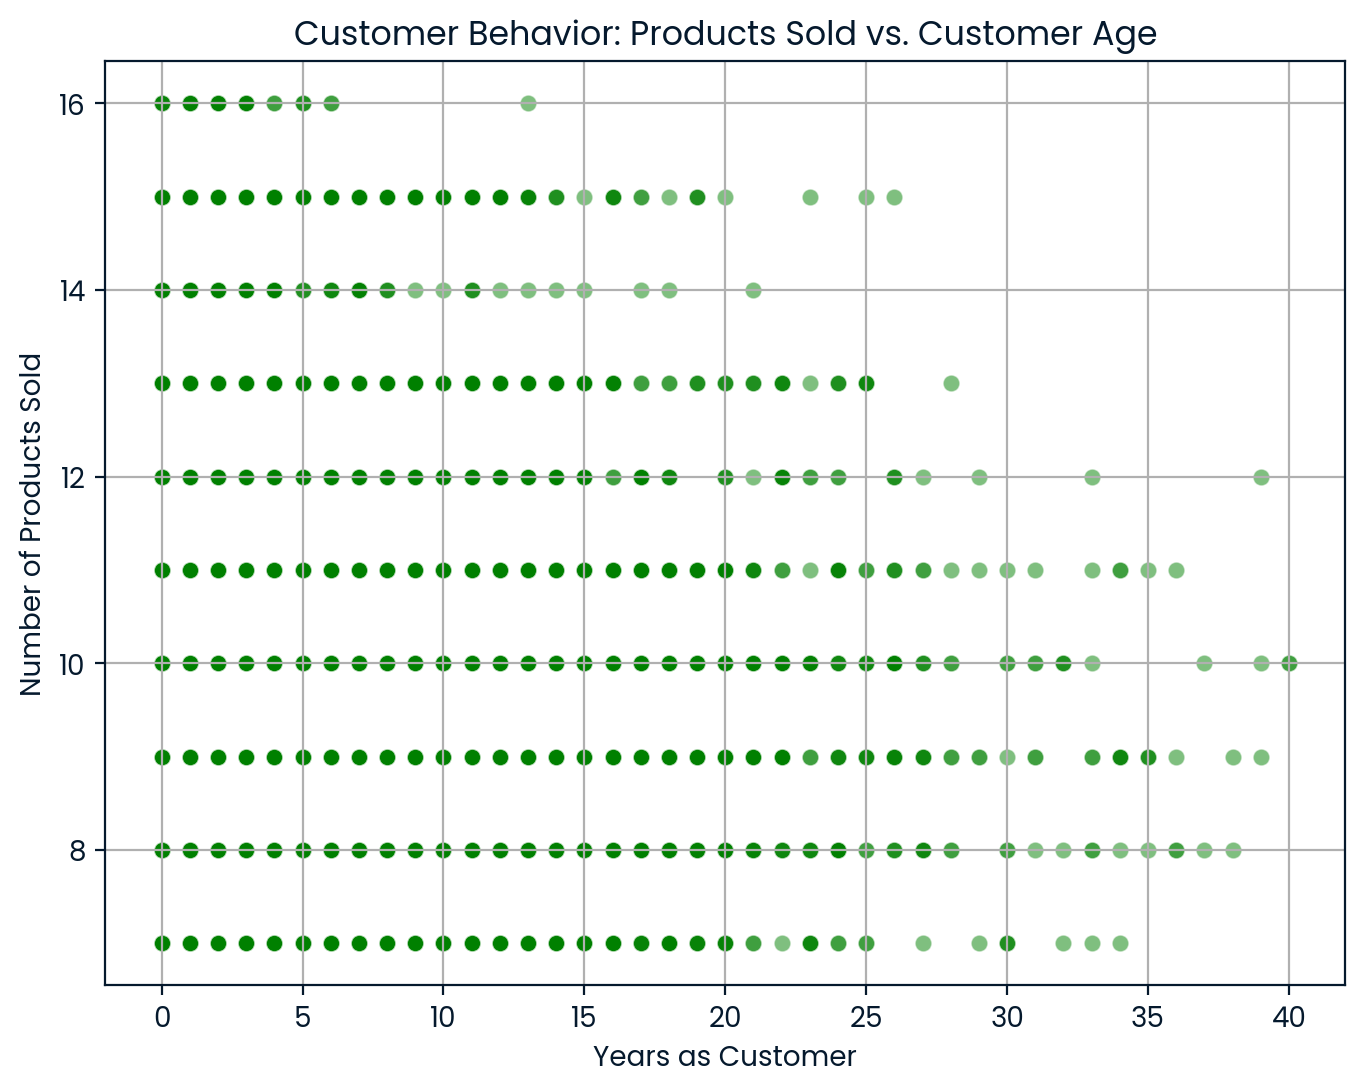

In [43]:
# Scatter plot: Customer engagement analysis - Site visits vs. Revenue
plt.figure(figsize=(8, 6))
sns.scatterplot(x='nb_site_visits', y='revenue_filled', data=p_sales, alpha=0.5)
plt.title('Customer Engagement: Site Visits vs. Revenue')
plt.xlabel('Number of Site Visits')
plt.ylabel('Revenue')
plt.grid(True)
plt.show()

# Scatter plot: Products Sold vs. Customer Age (years as customer)
plt.figure(figsize=(8, 6))
sns.scatterplot(x='years_as_customer', y='nb_sold', data=p_sales, alpha=0.5, color='green')
plt.title('Customer Behavior: Products Sold vs. Customer Age')
plt.xlabel('Years as Customer')
plt.ylabel('Number of Products Sold')
plt.grid(True)
plt.show()


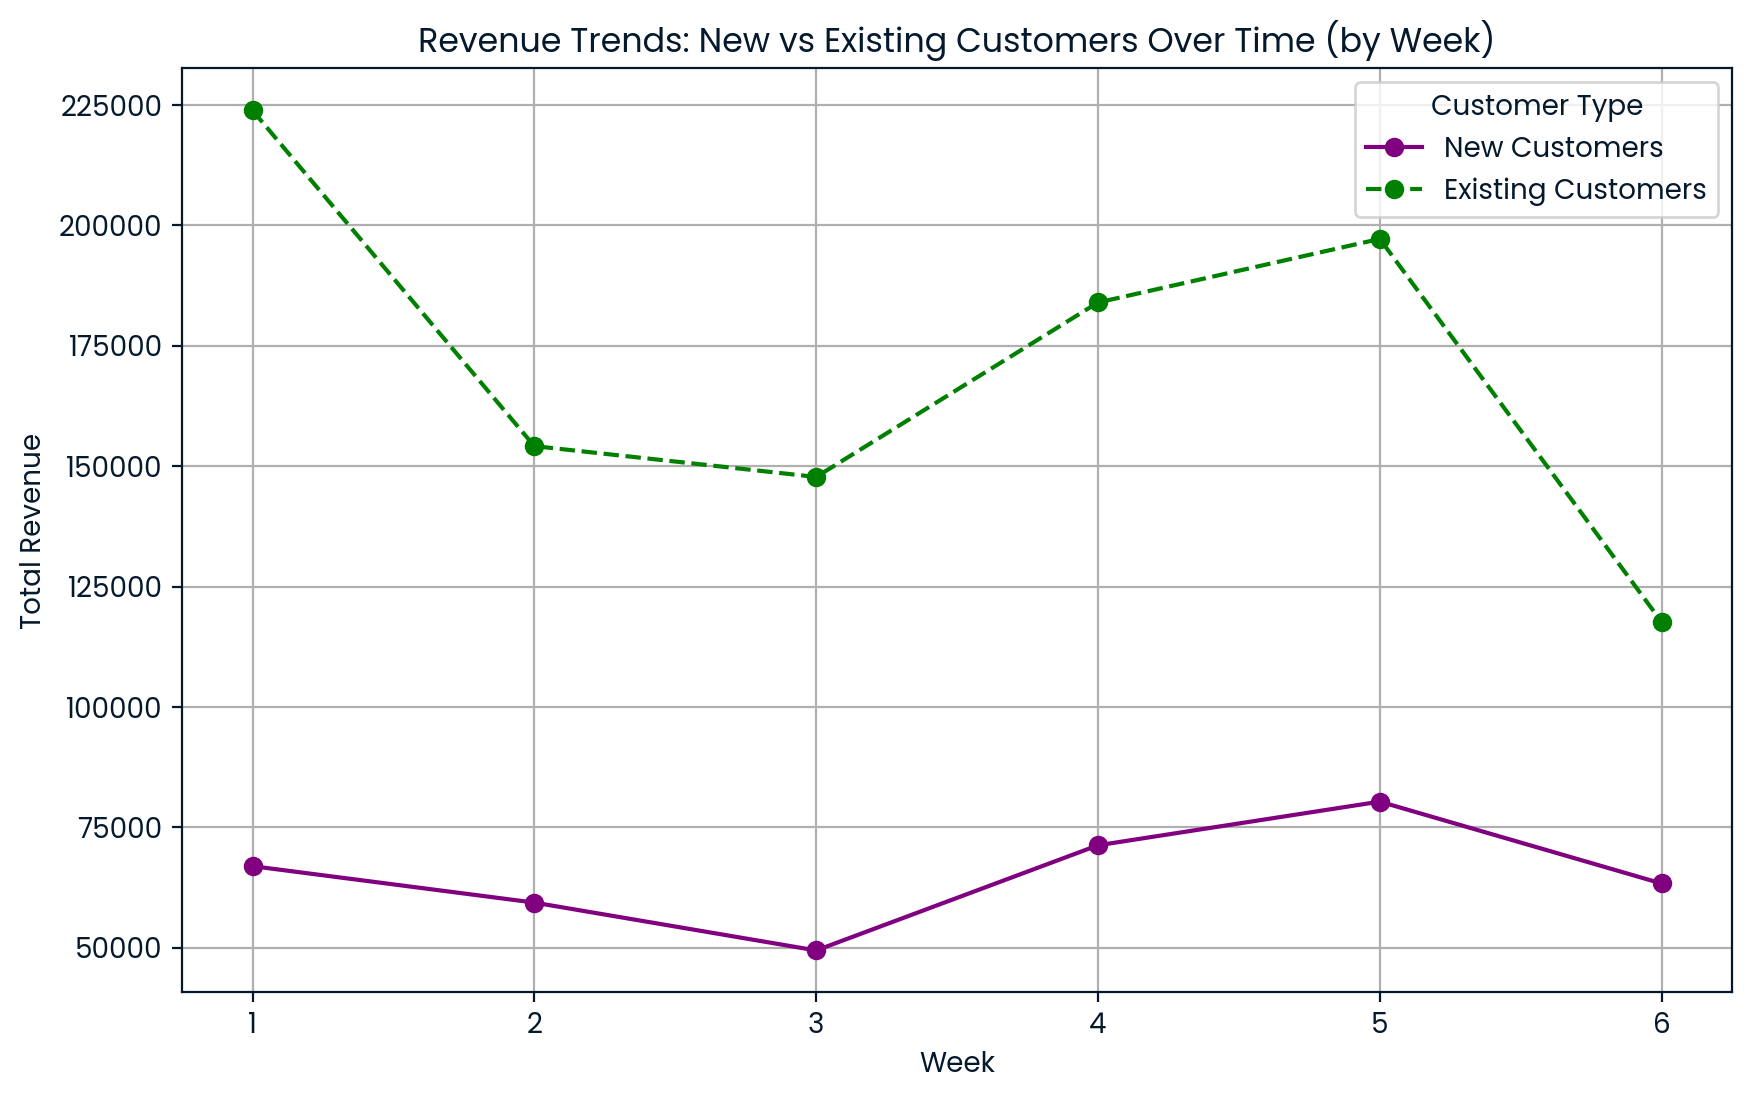

In [44]:
# Define new customers as those with 0 to 1 years as a customer
new_customers_data = p_sales[p_sales['years_as_customer'] <= 1]

# Group the new customers' data by week and calculate the total revenue per week
revenue_new_customers_by_week = new_customers_data.groupby('week')['revenue_filled'].sum()

# Define existing customers as those with more than 1 year as a customer
existing_customers_data = p_sales[p_sales['years_as_customer'] > 1]

# Group the existing customers' data by week and calculate the total revenue per week
revenue_existing_customers_by_week = existing_customers_data.groupby('week')['revenue_filled'].sum()

# Plot the revenue trends for both new and existing customers over time (by week)
plt.figure(figsize=(10, 6))

# Plot for new customers
plt.plot(revenue_new_customers_by_week.index, revenue_new_customers_by_week.values, marker='o', linestyle='-', color='purple', label='New Customers')

# Plot for existing customers
plt.plot(revenue_existing_customers_by_week.index, revenue_existing_customers_by_week.values, marker='o', linestyle='--', color='green', label='Existing Customers')

plt.title('Revenue Trends: New vs Existing Customers Over Time (by Week)')
plt.xlabel('Week')
plt.ylabel('Total Revenue')
plt.legend(title='Customer Type')
plt.grid(True)
plt.show()


In [45]:
# Calculate the average revenue per product sold
total_revenue = p_sales['revenue'].sum()
total_products_sold = p_sales['nb_sold'].sum()
average_revenue_per_product = total_revenue / total_products_sold

average_revenue_per_product


8.647702849210022